In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from shapely.geometry import Point
import matplotlib as mpl
from matplotlib.patches import Rectangle
import numpy as np
import matplotlib.patches as Patches

Imports data for counties with poor monitor/hotspot alignment, clips V6 data to these counties, reanalyzes hotspot alignment with the clipped v6 data

In [2]:
# 0 - 50 percent hotspot alignment county data (without grid cell measurments)
alignment_path = '/Users/griffinberonio/Documents/Holloway_Group/Data/monitor_data/V5_misaligned_hotspots_0-50'
alignment = pd.read_csv(alignment_path)

# alignment.head()

In [3]:

county_layer = alignment[['COUNTYFP','GEOID', 'NAME', 'NAMELSAD',
       'STUSPS', 'STATE_NAME', 'total_monitors', 'geometry', 'pct']]

county_shapefile = '/Users/griffinberonio/Documents/Holloway_Group/Data/map_shapefiles/tl_2023_us_county/tl_2023_us_county.shp'


states_to_include = [
    '01', '04', '05', '06', '08', '09', '10', '11', '12', '13',
    '16', '17', '18', '19', '20', '21', '22', '23', '24', '25',
    '26', '27', '28', '29', '30', '31', '32', '33', '34', '35',
    '36', '37', '38', '39', '40', '41', '42', '44', '45', '46',
    '47', '48', '49', '50', '51', '53', '54', '55', '56'
]

counties = gpd.read_file(county_shapefile)
# print(counties.columns)
counties_conus = counties[counties['STATEFP'].isin(states_to_include)]
counties_conus = counties_conus.drop(["COUNTYNS", 'LSAD', 'ALAND', 'AWATER', 'GEOIDFQ'], axis=1)
counties_conus = counties_conus.to_crs(epsg=4326)

monitor_layer = alignment[['total_monitors',
       'zones_in_hotspot', 'MICROSCALE', 'MIDDLE SCALE', 'NEIGHBORHOOD',
       'REGIONAL SCALE', 'URBAN SCALE', 'alignment_MICROSCALE',
       'alignment_MIDDLE SCALE', 'alignment_NEIGHBORHOOD',
       'alignment_URBAN SCALE', 'alignment_REGIONAL SCALE', 'pct',
       'GWRPM25_90th', 'monitor_geo']]


county_layer['geometry'] = gpd.GeoSeries.from_wkt(county_layer['geometry'])
county_plot = gpd.GeoDataFrame(county_layer,
                               geometry = county_layer.geometry,
                               crs = 5070)
county_plot = county_plot.to_crs(epsg=4326)

monitor_layer['monitor_geometry'] = gpd.GeoSeries.from_wkt(monitor_layer['monitor_geo'])
monitor_plot = gpd.GeoDataFrame(monitor_layer,
                                geometry = monitor_layer.monitor_geometry,
                                crs = 5070)
monitor_plot = monitor_plot.to_crs(epsg=4326)

county_plot

/var/folders/d1/xmw0d36x7fn39t0jfvtsbzk80000gn/T/ipykernel_48664/1907300507.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  county_layer['geometry'] = gpd.GeoSeries.from_wkt(county_layer['geometry'])
/var/folders/d1/xmw0d36x7fn39t0jfvtsbzk80000gn/T/ipykernel_48664/1907300507.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  monitor_layer['monitor_geometry'] = gpd.GeoSeries.from_wkt(monitor_layer['monitor_geo'])


,COUNTYFP,GEOID,NAME,NAMELSAD,STUSPS,STATE_NAME,total_monitors,geometry,pct
0,710,51710,Norfolk,Norfolk city,VA,Virginia,1.0,"POLYGON ((-76.33021 36.94206, -76.32567 36.963...",0.0
1,103,12103,Pinellas,Pinellas County,FL,Florida,2.0,"MULTIPOLYGON (((-82.69547 27.66549, -82.69391 ...",0.0
2,103,12103,Pinellas,Pinellas County,FL,Florida,2.0,"MULTIPOLYGON (((-82.69547 27.66549, -82.69391 ...",0.0
3,27,24027,Howard,Howard County,MD,Maryland,1.0,"POLYGON ((-77.18711 39.3406, -77.18381 39.3454...",0.0
4,35,41035,Klamath,Klamath County,OR,Oregon,1.0,"POLYGON ((-122.28997 42.12716, -122.28747 42.1...",0.0
...,...,...,...,...,...,...,...,...,...
165,245,48245,Jefferson,Jefferson County,TX,Texas,2.0,"POLYGON ((-94.44491 30.11302, -94.44326 30.113...",50.0
166,245,48245,Jefferson,Jefferson County,TX,Texas,2.0,"POLYGON ((-94.44491 30.11302, -94.44326 30.113...",50.0
167,27,6027,Inyo,Inyo County,CA,California,4.0,"POLYGON ((-118.79003 37.39403, -118.78675 37.3...",50.0
168,23,6023,Humboldt,Humboldt County,CA,California,2.0,"POLYGON ((-124.4086 40.4432, -124.39664 40.462...",50.0


<Axes: >

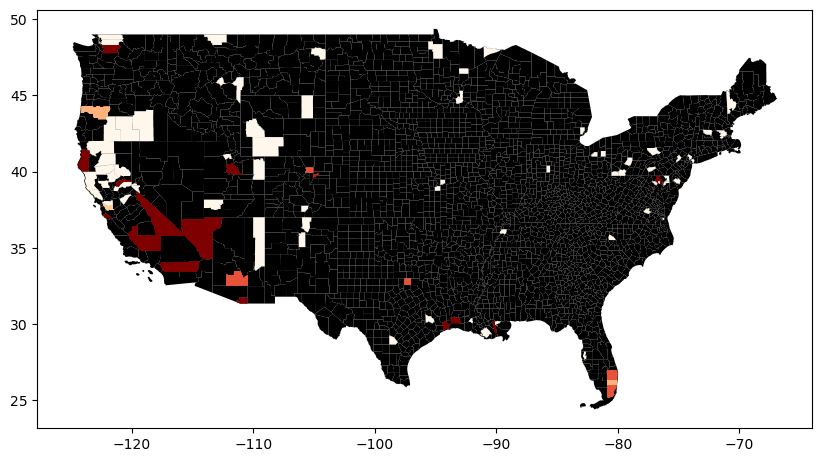

In [4]:
fig, ax = plt.subplots(figsize= (10,10))
counties_conus.plot(ax=ax,color='black', zorder=1)
county_plot.plot(ax=ax, column = 'pct', cmap='OrRd')

In [ ]:
len(county_plot['NAME'].unique())



            x          y
0  -76.330207  36.942061
0  -76.325665  36.963187
0  -76.321387  36.962332
0  -76.320252  36.957764
0  -76.315867  36.955351
..        ...        ...
0  -76.322931  36.903912
0  -76.326021  36.903722
0  -76.327827  36.914732
0  -76.329790  36.931948
0  -76.330207  36.942061

[145 rows x 2 columns]
